# Trabajo Práctico 3: Redes Neuronales

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np

## 1. Exploratory Analysis and Preprocessing

In [ ]:
from src.utils import dataset_summary, train_and_evaluate_model, advanced_comparison_table, print_training_summary, results_table
from src.graphics import plot_class_distribution, plot_images, plot_loss_history, plot_confusion_matrix
from src.data_splitting import train_val_test_split, split_summary
from src.preprocessing import normalize_image
from src.models import MLP
from src.metrics import evaluate_model, performance_report_table

In [4]:
X_img = np.load("Datos/X_images.npy")
y_img = np.load("Datos/y_images.npy")

### a) Exploratory Data Analysis

Dataset summary
----------------------------------------
Number of images: 809555
X shape: (809555, 28, 28)
y shape: (809555,)
X dtype: uint8
y dtype: uint8

Pixel values
----------------------------------------
Minimum: 0
Maximum: 255
Approximate mean: 44.1255
Approximate standard deviation: 84.4519
Statistics computed on 10000 images

Classes
----------------------------------------
Number of classes: 47
Classes found: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]

Dataset balance
----------------------------------------
Smallest class: Class 40 (2861 images)
Largest class: Class 1 (44604 images)
Max/min ratio: 15.59


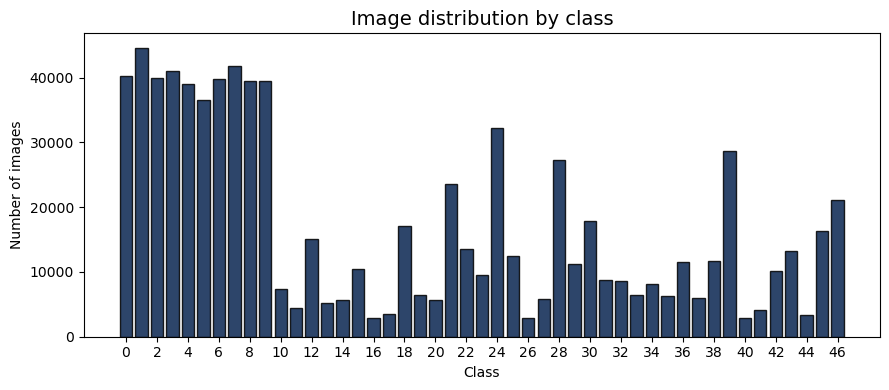

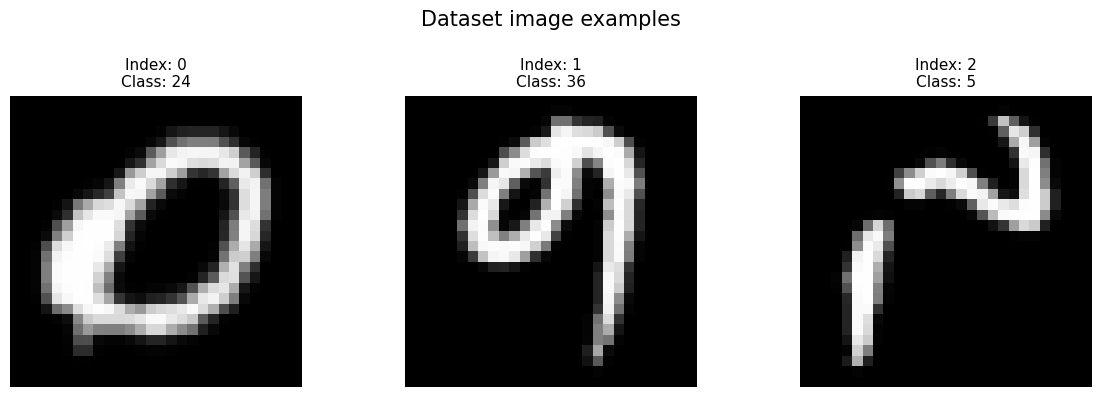

In [5]:
clases, cantidades = dataset_summary(X_img, y_img)
plot_class_distribution(clases, cantidades)

plot_images(X_img, y_img)

### b) Data Splitting

In [6]:
train, val, test = train_val_test_split(X_img, y_img)
split_summary(train, val, test)

Split summary
----------------------------------------
Train: 566667 images (70.0%)
Validation: 121410 images (15.0%)
Test: 121478 images (15.0%)

X_train shape: (566667, 28, 28)
X_val shape: (121410, 28, 28)
X_test shape: (121478, 28, 28)
y_train shape: (566667,)
y_val shape: (121410,)
y_test shape: (121478,)


### c) Normalizing

In [7]:
xtr, ytr = train
xval, yval = val
xtest, ytest = test

In [ ]:
n_train = 1000
n_val = 100
n_test = 100

# n_train = xtr.shape[0]
# n_val = xval.shape[0]
# n_test = xtest.shape[0]
n_classes = len(np.unique(y_img))

xtr_sample = xtr[:n_train]
xval_sample = xval[:n_val]
xtest_sample = xtest[:n_test]

ytr_sample = ytr[:n_train]
yval_sample = yval[:n_val]
ytest_sample = ytest[:n_test]

xtr_norm = normalize_image(xtr_sample).reshape(n_train, -1)
xval_norm = normalize_image(xval_sample).reshape(n_val, -1)
xtest_norm = normalize_image(xtest_sample).reshape(n_test, -1)

## 2. Basic Neural Network

### c) M0

In [ ]:
M0 = MLP(input_size = 28 * 28, hidden_size = 2, hidden_nodes = [128, 64],
         output_size = n_classes, full_batch_chunk_size = 50)

In [10]:
history_M0 = M0.fit(xtr_norm, ytr_sample, X_val = xval_norm, y_val = yval_sample,
    epochs = 200, verbose = False)

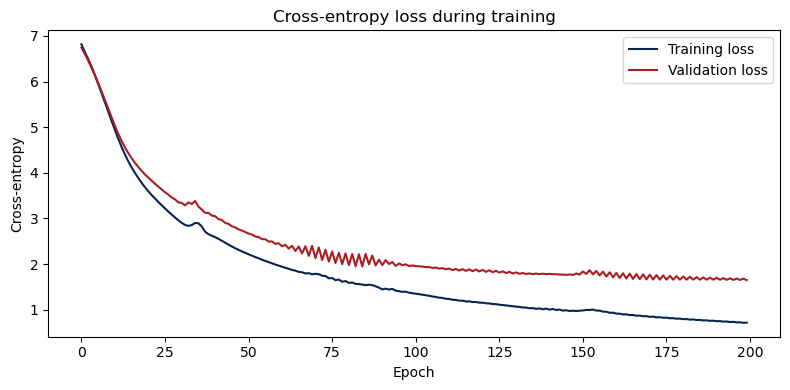

In [11]:
plot_loss_history(history_M0)

### d) Metrics

In [ ]:
train_results_M0 = evaluate_model(M0, xtr_norm, ytr_sample, n_classes)
val_results_M0 = evaluate_model(M0, xval_norm, yval_sample, n_classes)

In [ ]:
print_training_summary("M0", history_M0, train_results_M0, val_results_M0)

,Train,Validation
Accuracy,0.823,0.620
Cross-Entropy,0.706,1.650
F1-Score Macro,0.755,0.328


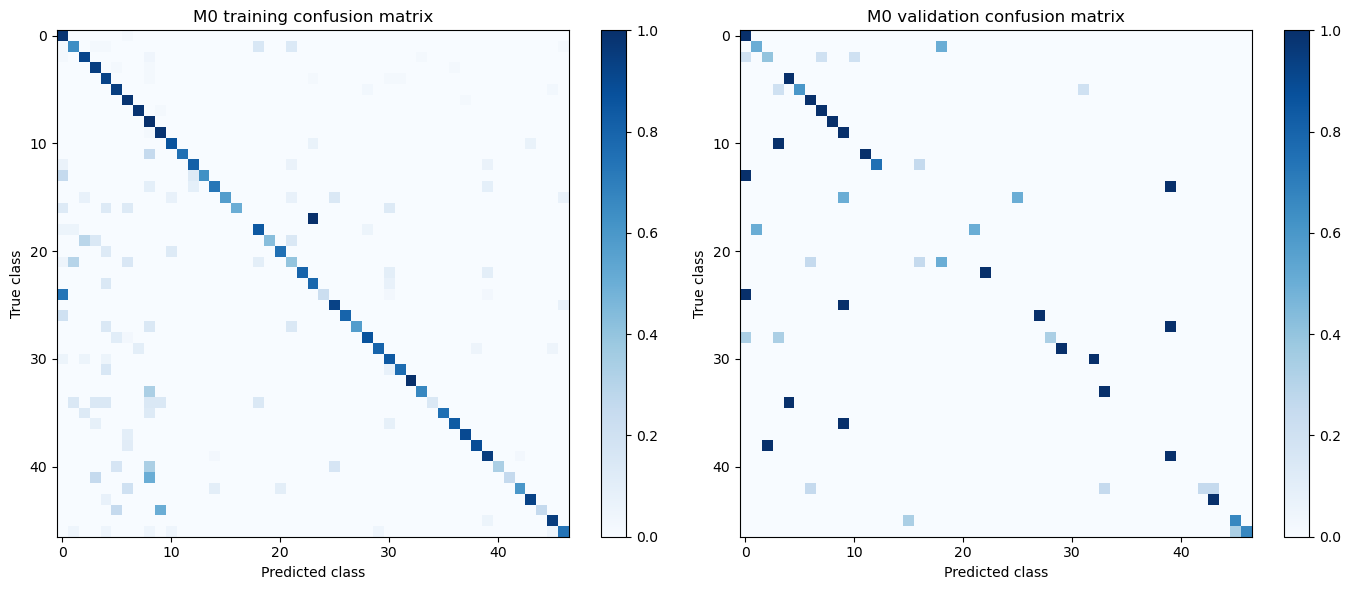

In [ ]:
performance_report_table(train_results_M0, val_results_M0)

plot_confusion_matrix(
    [
        train_results_M0["confusion_matrix"],
        val_results_M0["confusion_matrix"]
    ],
    titles = [
        "M0 training confusion matrix",
        "M0 validation confusion matrix"
    ],
    normalize = True
)

## 3. Advanced Neural Network

Utilizaremos la misma configuracion que M1, para ver como mejora en cada caso. Se entrenará un modelo por optimización.

In [14]:
model_config = {
    "input_size": 28 * 28,
    "hidden_size": 2,
    "hidden_nodes": [128, 64],
    "output_size": n_classes,
    "seed": 42
}

### a) Updated Models

In [15]:
advanced_results = {}

In [16]:
linear_schedule_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd",
    lr_schedule = "linear",
    lr_min = 1e-4
)

advanced_results["Linear schedule"] = train_and_evaluate_model(
    linear_schedule_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 70,
    batch_size = None
)

In [ ]:
exponential_schedule_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd",
    lr_schedule = "exponential",
    lr_decay = 0.95,
    lr_min = 1e-4
)

advanced_results["Exponential schedule"] = train_and_evaluate_model(
    exponential_schedule_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 70,
    batch_size = None
)

In [ ]:
mini_batch_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd"
)

advanced_results["Mini-batch SGD"] = train_and_evaluate_model(
    mini_batch_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 70,
    batch_size = 256
)

In [ ]:
adam_model = MLP(
    **model_config,
    learning_rate = 0.001,
    optimizer = "adam"
)

advanced_results["Adam"] = train_and_evaluate_model(
    adam_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 70,
    batch_size = None
)

In [20]:
l2_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd",
    l2_lambda = 0.001
)

advanced_results["L2"] = train_and_evaluate_model(
    l2_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 70,
    batch_size = None
)

In [21]:
early_stopping_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd",
    early_stopping = True,
    patience = 5,
    min_delta = 1e-4
)

advanced_results["Early stopping"] = train_and_evaluate_model(
    early_stopping_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 70,
    batch_size = None
)

Model,Epochs,Updates,Train Accuracy.,Val. Accuracy.,Train Cross-Entropy,Val. Cross-Entropy,Train F1,Val. F1
Linear schedule,70,70,0.091,0.080,3.674,3.765,0.023,0.022
Exponential schedule,70,70,0.052,0.040,3.791,3.879,0.015,0.014
Mini-batch SGD,70,70,0.182,0.150,3.442,3.541,0.062,0.046
Adam,70,70,0.918,0.580,0.413,1.520,0.874,0.312
L2,70,70,0.182,0.150,3.442,3.541,0.062,0.046
Early stopping,70,70,0.182,0.150,3.442,3.541,0.062,0.046


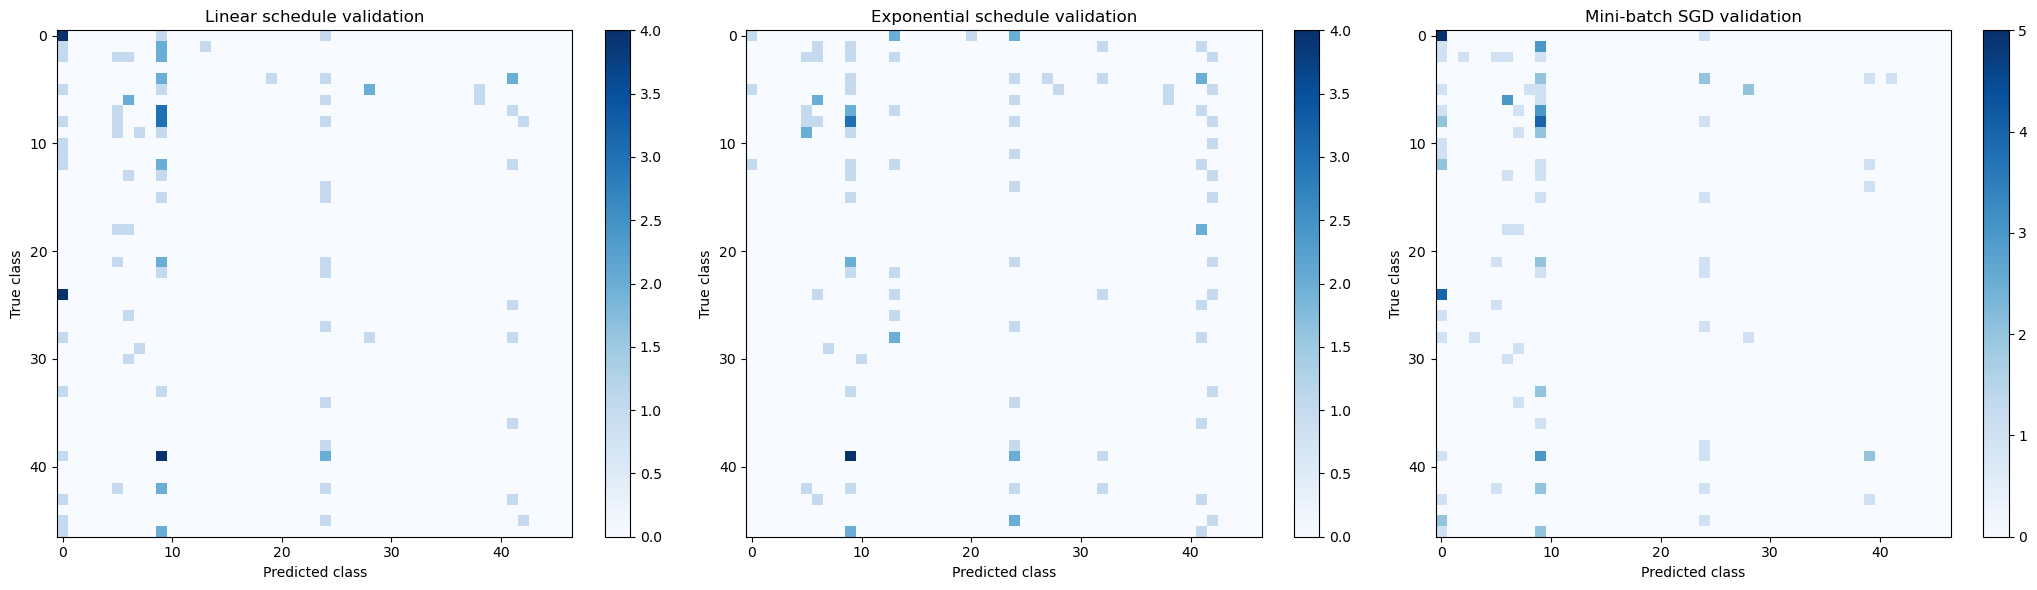

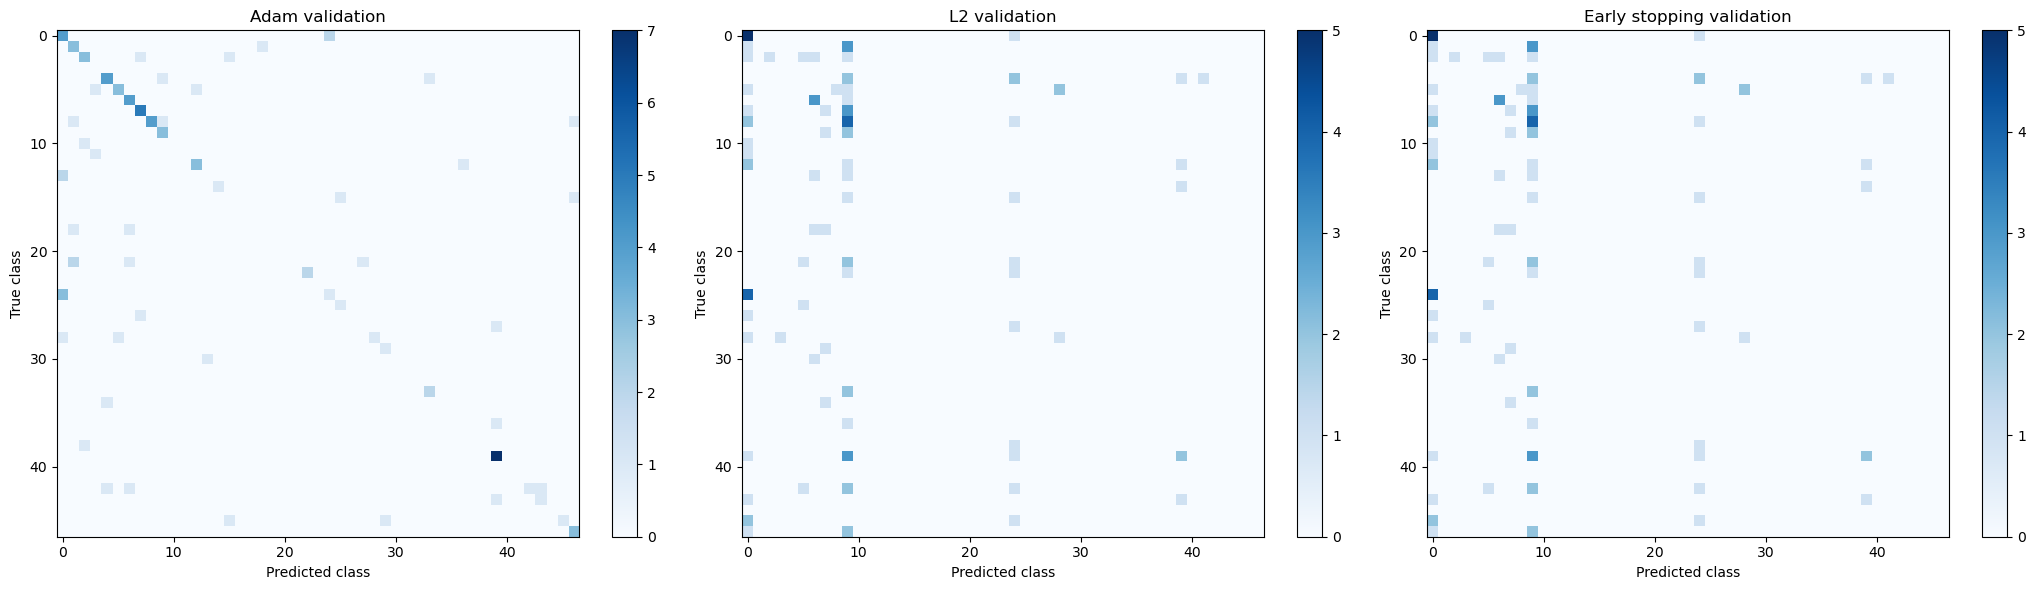

In [22]:
advanced_comparison_table(advanced_results)

confusion_matrix = []
titles = []

for model_name, results in advanced_results.items():
    confusion_matrix.append(results["val_metrics"]["confusion_matrix"])
    titles.append(f"{model_name} validation")

selected_models = [
    "Linear schedule",
    "Exponential schedule",
    "Mini-batch SGD"
]

plot_confusion_matrix(
    [advanced_results[name]["val_metrics"]["confusion_matrix"] for name in selected_models],
    titles = [f"{name} validation" for name in selected_models],
)

selected_models = [
    "Adam",
    "L2",
    "Early stopping"
]

plot_confusion_matrix(
    [advanced_results[name]["val_metrics"]["confusion_matrix"] for name in selected_models],
    titles = [f"{name} validation" for name in selected_models],
)


### b) Looking for M1

In [ ]:
from src.tuning import grid_search

Vamos a combinar el mejor modelo con el resto de optimizaciones posibles. Para la combinacion de mejor performance, se realizará un grid search sobre sus hiperparámetros.
uso adam, early stopping, minibatch, l2, debido a sus val accuracy y val F1

##### M1

In [ ]:
param_grid = {
    "input_size": [28 * 28],
    "hidden_size": [2],
    "hidden_nodes": [
        [128, 64],
        [256, 128],
        [256, 128, 64],
        [128, 64, 32]
    ],
    "output_size": [n_classes],
    "learning_rate": [0.01, 0.005, 0.001],
    "optimizer": ["adam"],
    "beta1": [0.9, 0.95],
    "beta2": [0.999, 0.995],
    "l2_lambda": [0.0, 0.1, 0.001, 0.01],
    "early_stopping": [True],
    "patience": [10, 15],
    "seed": [42]
}

In [ ]:
M1, best_params, best_score, results = grid_search(MLP, param_grid, xtr_norm, ytr_sample, xval_norm,
                                                           yval_sample, epochs = 50, batch_size = 256,)

## 4. PyTorch Model

In [43]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from src.models import TorchMLP
from torch import nn
from src.torch_utils import train_torch_model, evaluate_torch_model

### a) M2 and comparison with M1

##### M1

In [28]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


In [30]:
# Turn numpy arrays into PyTorch tensors:

X_train_tensor = torch.tensor(xtr_norm, dtype = torch.float32)
y_train_tensor = torch.tensor(ytr_sample, dtype = torch.long)

X_val_tensor = torch.tensor(xval_norm, dtype = torch.float32)
y_val_tensor = torch.tensor(yval_sample, dtype = torch.long)

X_test_tensor = torch.tensor(xtest_norm, dtype = torch.float32)
y_test_tensor = torch.tensor(ytest_sample, dtype = torch.long)

In [32]:
# Create TensorDatsets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [33]:
# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size = best_params["batch_size"],
    shuffle = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = best_params["batch_size"],
    shuffle = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size = best_params["batch_size"],
    shuffle = False
)

In [35]:
M2 = TorchMLP(
    input_size = best_params["input_size"],
    hidden_nodes = best_params["hidden_nodes"],
    output_size = best_params["output_size"]
).to(device)

In [37]:
# Define the loss function
loss_fn = nn.CrossEntropyLoss()

In [36]:
# define teh optimizer based on M1 parameters

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(
        M2.parameters(),
        lr = best_params["learning_rate"],
        weight_decay = best_params["l2_lambda"]
    )
else:
    optimizer = torch.optim.SGD(
        M2.parameters(),
        lr = best_params["learning_rate"],
        weight_decay = best_params["l2_lambda"]
    )

In [ ]:
# Train torch Model
history_M2 = train_torch_model(
    M2,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    epochs = best_params["epochs"],
    device = device
)

In [ ]:
# Evaluate on validation set
val_loss_M2, val_accuracy_M2 = evaluate_torch_model(
    M2,
    val_loader,
    loss_fn,
    device
)


##### M1 vs M2